# Exercise FLEXtopo

In this exercise, you will create a FlexTopo model. This notebook can then be used to run the model, the notebook also imports the relevant packages needed to run it on eWaterCycle.

You will need to change a few functions in the cells below in order to finish the code for the FlexTopo model. Make sure you use the percentages of the landscape units correctly.

Once the model is built, you will load the landscape data for the Wark catchment, plot it and classify the different landscape units.

Then, you are ready to run the model and calculate the discharge.

Remember to save your code!

 Look at the modeled discharge form both the FlexTopo and HVBmodel. In order to compare results you would either have to re-run the HBV model developed in Part 1, Exercise 2 in a new window. Or if you saved the plot showing the HBVmodel calculated discharge, use this. Where are the main differences in the hydrograph? Which processes are causing this?


In [1]:
# General python

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from datetime import datetime
from Weigfun import Weigfun
from plateau import plateau_func
import warnings
warnings.filterwarnings('ignore')


First, we need to build our model. You do this by coding in the following cells. Since we are working with a landscape-driven, semi-distributed model, we need to build each of the landscape units: plateau, hillslope and wetlands. We will start with the hillslope and wetland function. Since the plateau unit is more or less equivalent to the HBVmodel, the code structure is the same as the HVB model, and you do not have to code this part (it is already loaded in the first cell). After that, you can finalize the FlexTopo function. **NOTE** this is not written in BMI (yet).

### Hillslope

In [3]:
def hillslope_func(timestep, Par, forcing, Fluxes, States):
	# HBVpareto Calculates values of 3 objective functions for HBV model

	I_max = Par[0]
	Ce = Par[1]
	Su_max = Par[2]
	beta = Par[3]
	D = Par[4]
	Kf = Par[5]
	Qo = forcing['Qo']
	Prec = forcing['Prec']
	Etp = forcing['Etp']


	t_max = len(Prec)
	Si = States[:,0]
	Su = States[:,1]
	Sf = States[:,2]

	Ei_dt = Fluxes[:,0]
	Ea_dt = Fluxes[:,1]
	Qf_dt = Fluxes[:,2]
	Qus_dt = Fluxes[:,3]

	dt = 1
	t = timestep

	P_dt = Prec[t] * dt
	Ep_dt = Etp[t] * dt

	'''UPDATE'''
	# Interception Reservoir
	...

	'''UPDATE'''
	# Unsaturated Reservoir
    ...

	'''UPDATE'''
	# Transpiration
    ...

	'''UPDATE'''
	# Preferential Percolation
	Qus_dt = D * ...

	'''UPDATE'''
	# Fast Reservoir
	Sf[t] = Sf[t] + (1-D) * ...
	Qf_dt[t] = ...
	Sf[t] = ...
	...

	# Save output
	States[:,0] = Si
	States[:,1] = Su
	States[:,2] = Sf

	Fluxes[:,0] = Ei_dt
	Fluxes[:,1] = Ea_dt
	Fluxes[:,2] = Qf_dt
	Fluxes[:,3] = Qus_dt

	return(Fluxes, States)

IndentationError: unindent does not match any outer indentation level (<string>, line 37)

### Wetlands

In [4]:
def wetland_func(timestep, Par, forcing, Fluxes, States, Ss, landscape_per):
	# HBVpareto Calculates values of 3 objective functions for HBV model

	I_max = Par[0]
	Ce = Par[1]
	Su_max = Par[2]
	beta = Par[3]
	C_max = Par[4]
	Kf = Par[5]

	Qo = forcing['Qo']
	Prec = forcing['Prec']
	Etp = forcing['Etp']


	t_max = len(Prec)
	Si = States[:,0]
	Su = States[:,1]
	Sf = States[:,2]

	Ei_dt = Fluxes[:,0]
	Ea_dt = Fluxes[:,1]
	Qf_dt = Fluxes[:,2]

	dt = 1
	t = timestep

	P_dt = Prec[t] * dt
	Ep_dt = Etp[t] * dt
	'''UPDATE'''
	# Interception Reservoir
	...

	'''UPDATE'''
	# Unsaturated Reservoir
	...

	'''UPDATE'''
	# Transpiration
	...

	'''UPDATE'''
	# Capillary rise
	Qr_dt = (1-Su[t]/Su_max) * ...
	Qr_dt = min(Qr_dt, ... #check if the groundwater has enough water (note: you need to use the landscape percentage!!!)

	if ((Su[t] + Qr_dt) > Su_max):
		Qr_dt = Su_max - Su[t]

	'''UPDATE'''
	Su[t] = Su[t] + ...
	Ss[t] = Ss[t] - ... * landscape_per

	if t < t_max - 1:
		Su[t+1] = Su[t]

	'''UPDATE'''
	# Fast Reservoir
	...


	# Save output
	States[:,0] = Si
	States[:,1] = Su
	States[:,2] = Sf

	Fluxes[:,0] = Ei_dt
	Fluxes[:,1] = Ea_dt
	Fluxes[:,2] = Qf_dt

	return(Fluxes, States, Ss)

SyntaxError: '(' was never closed (477591524.py, line 45)

### Flextopo

In [5]:
def FLEXtopo(ParPlateau, ParHillslope, ParWetland, ParCatchment, forcing, landscapes):

	# Parameters and constants
	T_lag = ParCatchment[1]
	Ks = ParCatchment[0]
	dt = 1
	t_max = len(forcing['Qo'])

	# Initialize states
	States_plateau = np.zeros((t_max,3))
	States_hillslope = np.zeros((t_max,3))
	States_wetland = np.zeros((t_max,3))
	Ss = np.zeros((t_max,1))

	# Initialize fluxes
	Fluxes_plateau = np.zeros((t_max,4))
	Fluxes_hillslope = np.zeros((t_max,4))
	Fluxes_wetland = np.zeros((t_max,3))
	Qs_dt = np.zeros(t_max)
	Q_tot_dt = np.zeros(t_max)

	# Loop over time
	for t in range(0,t_max):

		# Plateau
		Fluxes_plateau, States_plateau = plateau_func(t, ParPlateau, forcing, Fluxes_plateau, States_plateau)
		# Hillslope
		Fluxes_hillslope, States_hillslope = hillslope_func(t, ParHillslope, forcing, Fluxes_hillslope, States_hillslope)

		# Wetland
		Fluxes_wetland, States_wetland, Ss = wetland_func(t, ParWetland, forcing, Fluxes_wetland, States_wetland, Ss, landscapes[2])

		# Slow Reservoir
		'''UPDATE'''
		Ss[t] = Ss[t] + ... * landscapes[0] + ... * landscapes[1]
		Qs_dt = dt * Ks * Ss[t]
		Ss[t] = Ss[t] - min(Qs_dt,Ss[t])
		if t < t_max - 1:
			Ss[t+1] = Ss[t]

		'''UPDATE'''
		Q_tot_dt[t] = Qs_dt + ... * landscapes[0] + ... * landscapes[1] +  ... * landscapes[2]

	# Offset Q
	weigths = Weigfun(T_lag)

	Qm = np.convolve(Q_tot_dt, weigths)
	Qm = Qm[0:t_max]

	return(Qm)

## Landscapes

In the folder `wark_data` you can find data from the Wark region (for this exercise the data is in the same directory). In the cells below the data is loaded into arrays and plotted. Complete the code for plotting the HAND data. What can these plots tell us about the landscape in the catchment?

In [6]:
DEM = np.genfromtxt('dem.asc',  dtype=float, autostrip=True)
slope = np.genfromtxt('slope.asc',  dtype=float, autostrip=True)
hand = np.genfromtxt('HAND.asc',  dtype=float, autostrip=True)
basin = np.genfromtxt('basin.asc',  dtype=float, autostrip=True)

Ellipsis

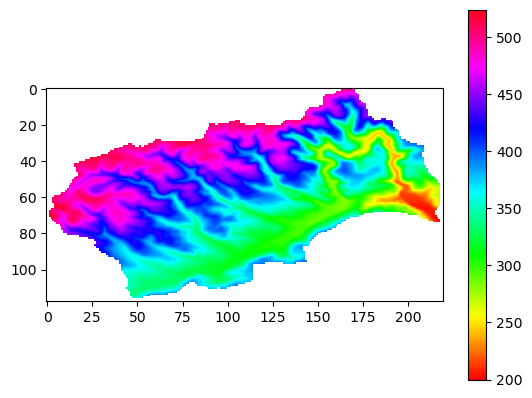

<Figure size 640x480 with 0 Axes>

In [7]:
# plot DEM
plt.figure(1)
DEM[DEM==-9999]=np.nan
plt.imshow(DEM, cmap='hsv')
plt.colorbar()

'''UPDATE'''
# plot HAND
plt.figure(2)
...
...

## Classification

Make a landscape classification for the Wark catchment. Use the HRU classification matrix ( see lecture slides “Models Lecture 4”). Set the HAND threshold to 5m and the slope threshold to 11%. Basin is defined for all indices larger than 0 in the basin array. Calculate the percentages of hillslope, wetland and plateau in the area.

In [8]:
'''UPDATE'''
# Make landscape classification
hillslope = np.array(slope) > ...
plateau = (np.array(hand) > 5) ...
wetland = (np.array(hand) <= 5) ...
basin = np.array(basin) > 0

'''UPDATE'''
hillslope_per = float(np.sum(hillslope))/float(np.sum(basin))
wetland_per = ...
plateau_per = ...

landscapes=np.zeros((118,220))
landscapes[plateau] = 1
landscapes[hillslope] = 2
landscapes[wetland] = 3

# Plot landscapes
cmap = mpl.colors.ListedColormap(['white', 'red', 'green', 'blue'])
bounds = [0, 1, 2, 3, 4]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

plt.figure(3)
plt.imshow(landscapes, cmap=cmap, norm=norm)
plt.colorbar()
plt.show()

SyntaxError: invalid syntax (1023005722.py, line 4)

## Run Model

Load the forcing data from the text file in the `wark_data` folder (again locally here). Define the parameters as you did before for the HBV model, now you need to define them for Plateau, Hillslope and Wetland areas. Ks and T_lag are defined for the whole catchment. Define the landscape percentages.

In [9]:
# Assuming the text file has three columns: year, month, day
# Use pandas to read the text file
df = pd.read_csv('forcingWark.txt', sep='\s+', header=None, names=['month', 'day', 'year', 'Qo', 'Prec', 'Etp'], dtype=float)

# Create a new column that combines the year, month, and day into a datetime object
df['date'] = pd.to_datetime(df[['day', 'month', 'year']])

forcing = df

In [10]:
                  #      I_max Ce Su_max beta Pmax    Kf  
ParPlateau   = np.array([3.2, 0.50, 17.40, 0.95, 1.76, 0.91])   
                  #      I_max Ce Su_max beta D     Kf  
ParHillslope = np.array([3.25, 0.50, 321.99, 0.99, 0.4, 0.97])
                  #      I_max Ce Su_max beta C_max     Kf  
ParWetland   = np.array([9.94, 0.50, 53.25, 0.70, 0.65, 0.45])
              # Ks T_lag
ParCatchment = np.array([0.0281, 2.21])

'''UPDATE'''
# Landscape percentages
landscape_per = np.array([..., ..., ...])

## Calculate the discharge 

Use the FLEXtopo model to calculate the discharge. Plot it together with the measured discharge.

Compare these results to the results you got from calculating the discharge with the HBVmodel (see “Lumped Models: Model Excersise2: Lumped Conceptual Model”). Where are the main differences in the hydrograph? Which processes are causing this?


In [11]:
Qm = FLEXtopo(ParPlateau, ParHillslope, ParWetland, ParCatchment, forcing, landscape_per)
Qo = forcing['Qo']	

fig, ax = plt.subplots(figsize=(10,6))

ax.plot(df['date'], Qo, label='Observed')
ax.plot(df['date'], Qm, label='Modelled')
ax.legend()
ax.set_title('Discharge - FLEXtopo')

ax.set_xlabel('Date')
ax.set_ylabel('Flow')

NameError: name 'hillslope_func' is not defined